# Can engaged vs disengaged trials be predicted from the trial mode?

Same target, models and tests as `state_prediction.ipynb`, but the inputs are **trial modes**: the whole-trial clusters from `3_trial_modes/trial_modes_proficient.ipynb` (02-10-2026 syllables, `Functions/trial_modes.py`). Each trial is one categorical label (one-hot; background / unembedded trials are their own category `m-1`), lagged like the syllables.

* A mode describes the **whole trial**, Choice and ITI included, so trial t's own mode is used only in `concurrent` mode, whose baseline includes trial t's outcome. `predictive` mode uses trials t-1 … t-`LAG` only.
* The question beyond "do modes predict the state" is whether they add anything **over the syllable features** they are built from: one categorical label per trial (≈15 levels) vs 40 continuous per-trial features. Five models are compared: `base`, `+modes`, `+syllables`, `+both`, and `modes` alone.
* Mode usage is session-centred (`CENTER='session'`), as the syllables are.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
sys.path.insert(0, str(_p / 'GLM-HMM' / 'transition_prediction'))
import paper_style as ps
import tp_data as td
import tp_models as tm
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
TRIAL_MODES = td.TRIAL_MODES_FILE
TARGET = 'disengaged'
MODES = ['predictive', 'concurrent']
LAGS = [1, 2, 3, 5]
MODE, LAG = 'concurrent', 2        # sections 3-4
CENTER = 'session'
CV, N_SPLITS, N_LD1_BINS = 'mouse', 5, 3

## 1. Data

In [3]:
df = td.build_trial_table(trial_modes=TRIAL_MODES)
print(f"{df['eid'].nunique()} sessions, {df['mouse_name'].nunique()} mice, {len(df)} trials")
print(f"trials without a mode (unembedded or background): {(df['trial_mode'] == -1).mean():.1%}")
df['trial_mode'].value_counts(normalize=True).sort_index().round(3).to_frame('fraction').T

244 sessions, 56 mice, 152377 trials
trials without a mode (unembedded or background): 3.9%


trial_mode,-1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
fraction,0.039,0.117,0.116,0.081,0.077,0.055,0.053,0.083,0.063,0.046,0.052,0.042,0.046,0.029,0.026,0.041,0.019,0.014


### 1b. Model-free: which modes are disengaged?
Per session, P(disengaged | mode) minus the session's overall P(disengaged); averaged within mouse, then median across mice (Wilcoxon across mice, FDR). Modes are also described by accuracy, to see how much of this is just "error trials".

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


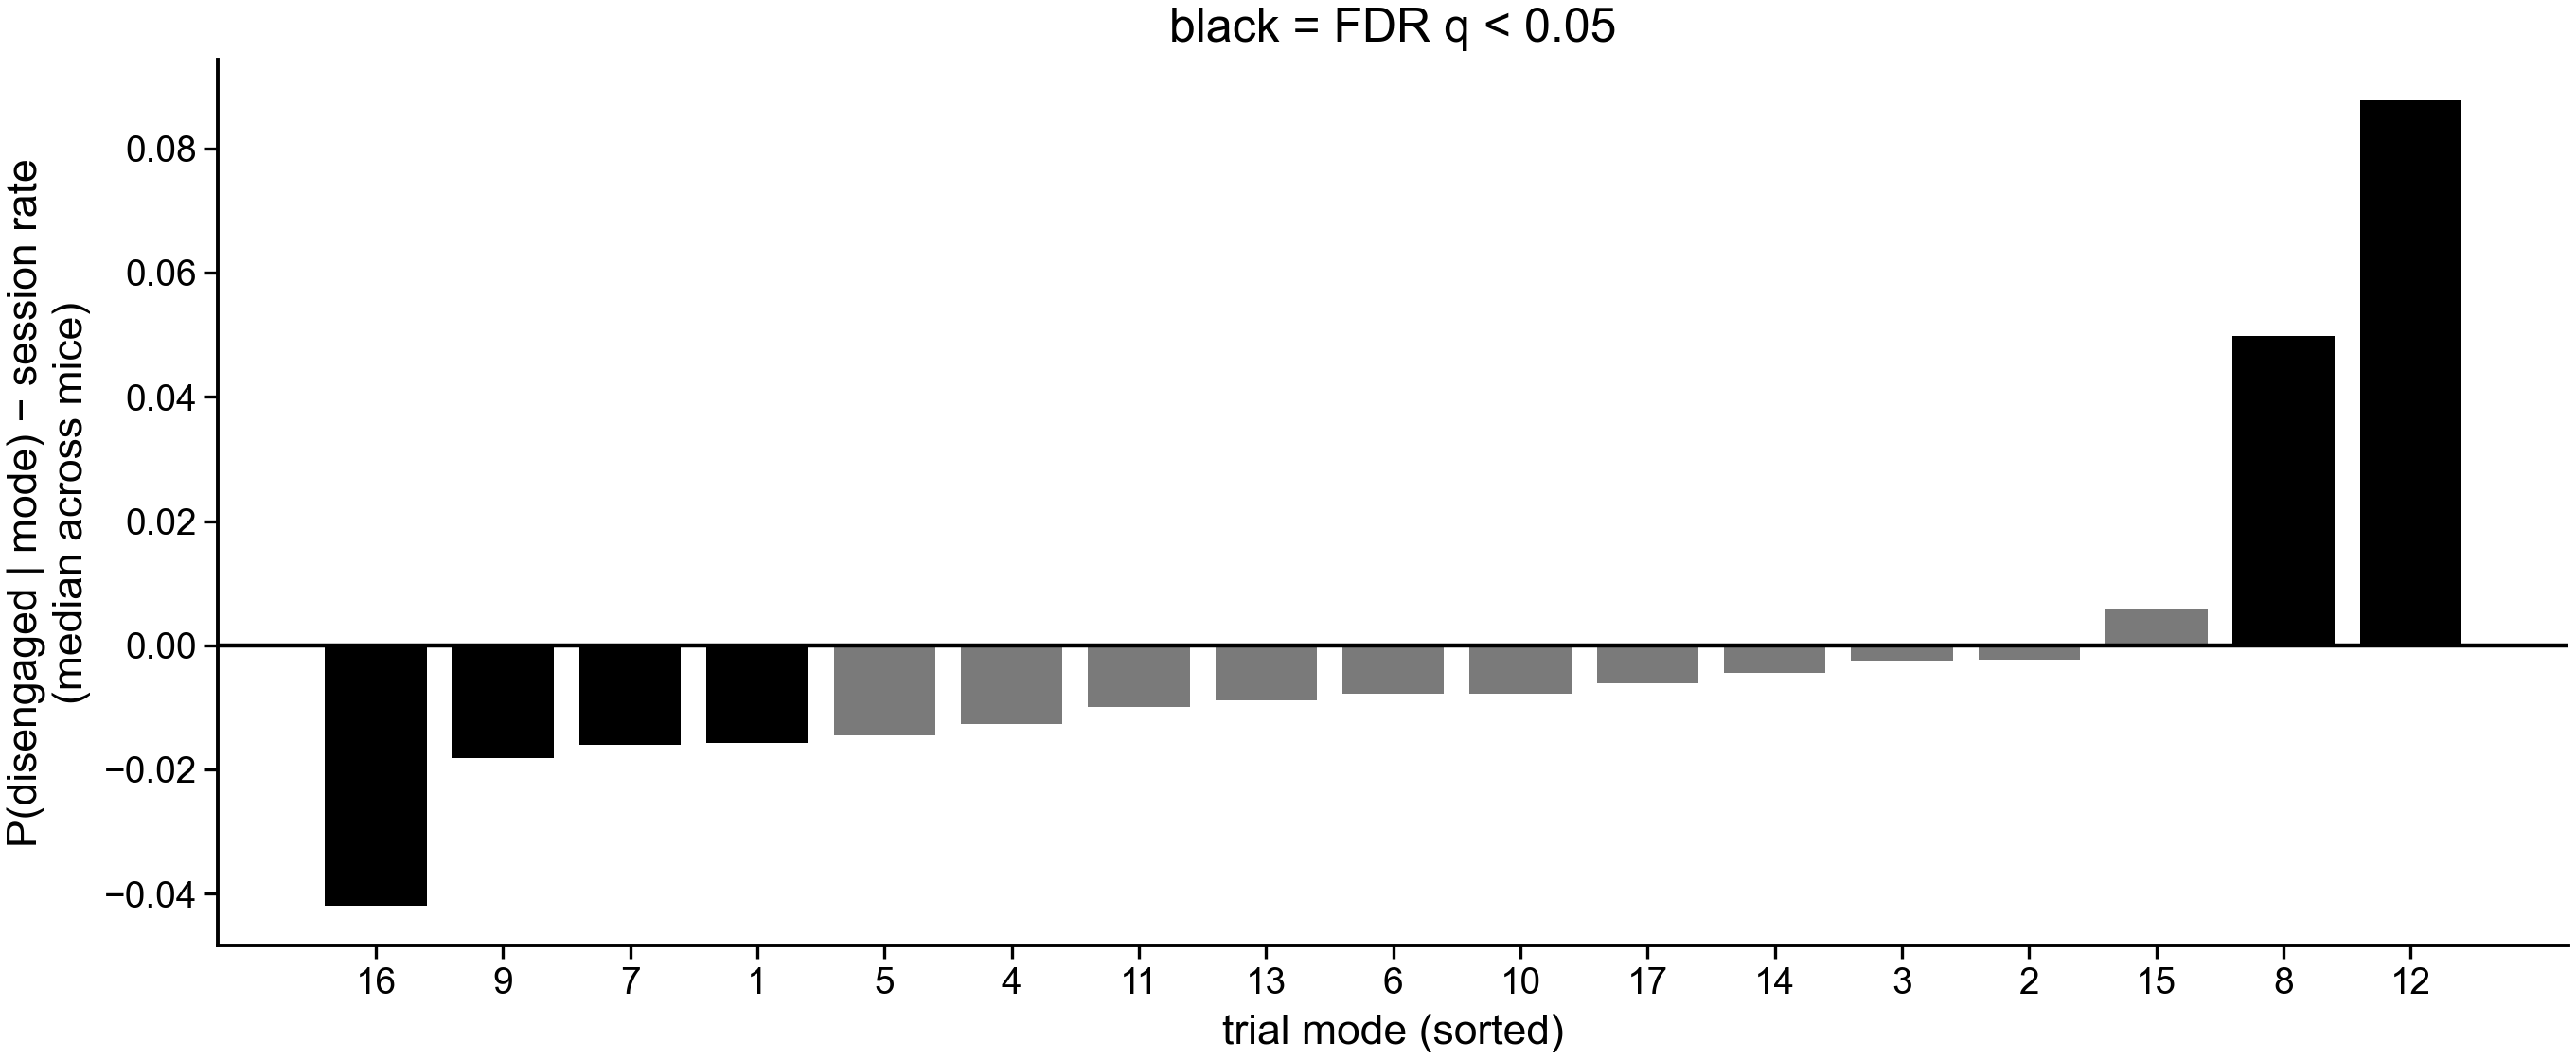

,mode,n_mice,median_excess,p,q,frac_correct,share
15,16,34,-0.042,0.001,0.005,0.878,0.020
8,9,56,-0.018,0.007,0.019,0.919,0.048
6,7,56,-0.016,0.001,0.003,0.902,0.086
0,1,56,-0.016,0.001,0.005,0.874,0.121
4,5,56,-0.014,0.038,0.091,0.904,0.058
3,4,56,-0.013,0.093,0.197,0.776,0.080
10,11,56,-0.010,0.125,0.213,0.879,0.044
12,13,53,-0.009,0.740,0.898,0.896,0.030
5,6,55,-0.008,0.280,0.423,0.848,0.055
9,10,56,-0.008,0.300,0.423,0.877,0.054


In [4]:
d = df[df['trial_mode'] >= 0].copy()
d['rate_session'] = d.groupby('eid')['disengaged'].transform('mean')
cell = d.groupby(['mouse_name', 'eid', 'trial_mode']).agg(p=('disengaged', 'mean'), base=('rate_session', 'first'),
                                                          n=('disengaged', 'size'))
cell = cell[cell['n'] >= 5]
cell['excess'] = cell['p'] - cell['base']
per_mouse = cell.groupby(['mouse_name', 'trial_mode'])['excess'].mean().unstack()
rows = []
for m in per_mouse.columns:
    x = per_mouse[m].dropna()
    rows.append(dict(mode=int(m), n_mice=len(x), median_excess=x.median(),
                     p=wilcoxon(x).pvalue if len(x) >= 6 else np.nan))
res = pd.DataFrame(rows)
res['q'] = np.nan
ok = res['p'].notna()
res.loc[ok, 'q'] = multipletests(res.loc[ok, 'p'], method='fdr_bh')[1]
acc = d.groupby('trial_mode').agg(frac_correct=('rewarded', lambda r: (r == 1).mean()), share=('eid', 'size'))
acc['share'] /= acc['share'].sum()
res = res.merge(acc, left_on='mode', right_index=True).sort_values('median_excess')
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(res['mode'].astype(str), res['median_excess'], color=np.where(res['q'] < 0.05, 'k', ps.NEUTRAL))
ax.axhline(0, color='k', lw=0.8)
ax.set(xlabel='trial mode (sorted)', ylabel='P(disengaged | mode) − session rate\n(median across mice)')
ax.set_title('black = FDR q < 0.05')
fig.tight_layout(); plt.show()
res.round(3)

## 2. Prediction: modes vs syllables vs both, over lags

In [5]:
rows = []
for mode in MODES:
    for lag in LAGS:
        Xb, Xm, y, meta = td.design(df, TARGET, lag=lag, mode=mode, center=CENTER, features='modes')
        _, Xs, _, _ = td.design(df, TARGET, lag=lag, mode=mode, center=CENTER, features='syllables')
        mats = {'base': Xb, 'modes': Xm, 'base+modes': pd.concat([Xb, Xm], axis=1),
                'base+syllables': pd.concat([Xb, Xs], axis=1),
                'base+both': pd.concat([Xb, Xs, Xm], axis=1)}
        for name, X in mats.items():
            p, p0, _ = tm.cross_validate(X, y, meta, CV, N_SPLITS)
            s = tm.scores(y, p, p0)
            pu = tm.per_unit_scores(y, {'m': p, 'null': p0}, meta, unit='eid', min_events=10)
            rows.append(dict(mode=mode, lag=lag, model=name, n_features=X.shape[1], auc=s['auc'],
                             ll_skill=s['ll_skill'], auc_within=pu['m_auc'].median()))
        print(f"{mode} lag {lag}: " + ', '.join(f"{r['model']}={r['ll_skill']:.3f}" for r in rows[-5:]), flush=True)
sweep = pd.DataFrame(rows)
sweep.to_csv(td.HERE / 'results_mode_state_sweep.csv', index=False)
sweep.pivot_table(index=['mode', 'lag'], columns='model', values=['ll_skill', 'auc_within']).round(3)

predictive lag 1: base=0.030, modes=0.005, base+modes=0.031, base+syllables=0.039, base+both=0.038


predictive lag 2: base=0.044, modes=0.008, base+modes=0.045, base+syllables=0.054, base+both=0.053


predictive lag 3: base=0.053, modes=0.010, base+modes=0.053, base+syllables=0.064, base+both=0.063


predictive lag 5: base=0.066, modes=0.013, base+modes=0.066, base+syllables=0.076, base+both=0.075


concurrent lag 1: base=0.081, modes=0.010, base+modes=0.081, base+syllables=0.090, base+both=0.089


concurrent lag 2: base=0.093, modes=0.012, base+modes=0.093, base+syllables=0.102, base+both=0.101


concurrent lag 3: base=0.101, modes=0.014, base+modes=0.100, base+syllables=0.111, base+both=0.110


concurrent lag 5: base=0.112, modes=0.016, base+modes=0.111, base+syllables=0.121, base+both=0.119


auc_within                                            ll_skill                                           
model                base base+both base+modes base+syllables  modes     base base+both base+modes base+syllables  modes
mode       lag                                                                                                          
concurrent 1        0.744     0.753      0.746          0.756  0.569    0.081     0.089      0.081          0.090  0.010
           2        0.766     0.767      0.767          0.768  0.578    0.093     0.101      0.093          0.102  0.012
           3        0.774     0.778      0.777          0.782  0.582    0.101     0.110      0.100          0.111  0.014
           5        0.781     0.787      0.777          0.791  0.590    0.112     0.119      0.111          0.121  0.016
predictive 1        0.616     0.631      0.626          0.634  0.543    0.030     0.038      0.031          0.039  0.005
           2        0.643     0.656      0.639          0.658  0.556    0.044     0.053      0.045          0.054  0.008
           3        0.656     0.665      0.653          0.669  0.565    0.053     0.063      0.053          0.064  0.010
           5        0.667     0.676      0.667          0.678  0.577    0.066     0.075      0.066          0.076  0.013

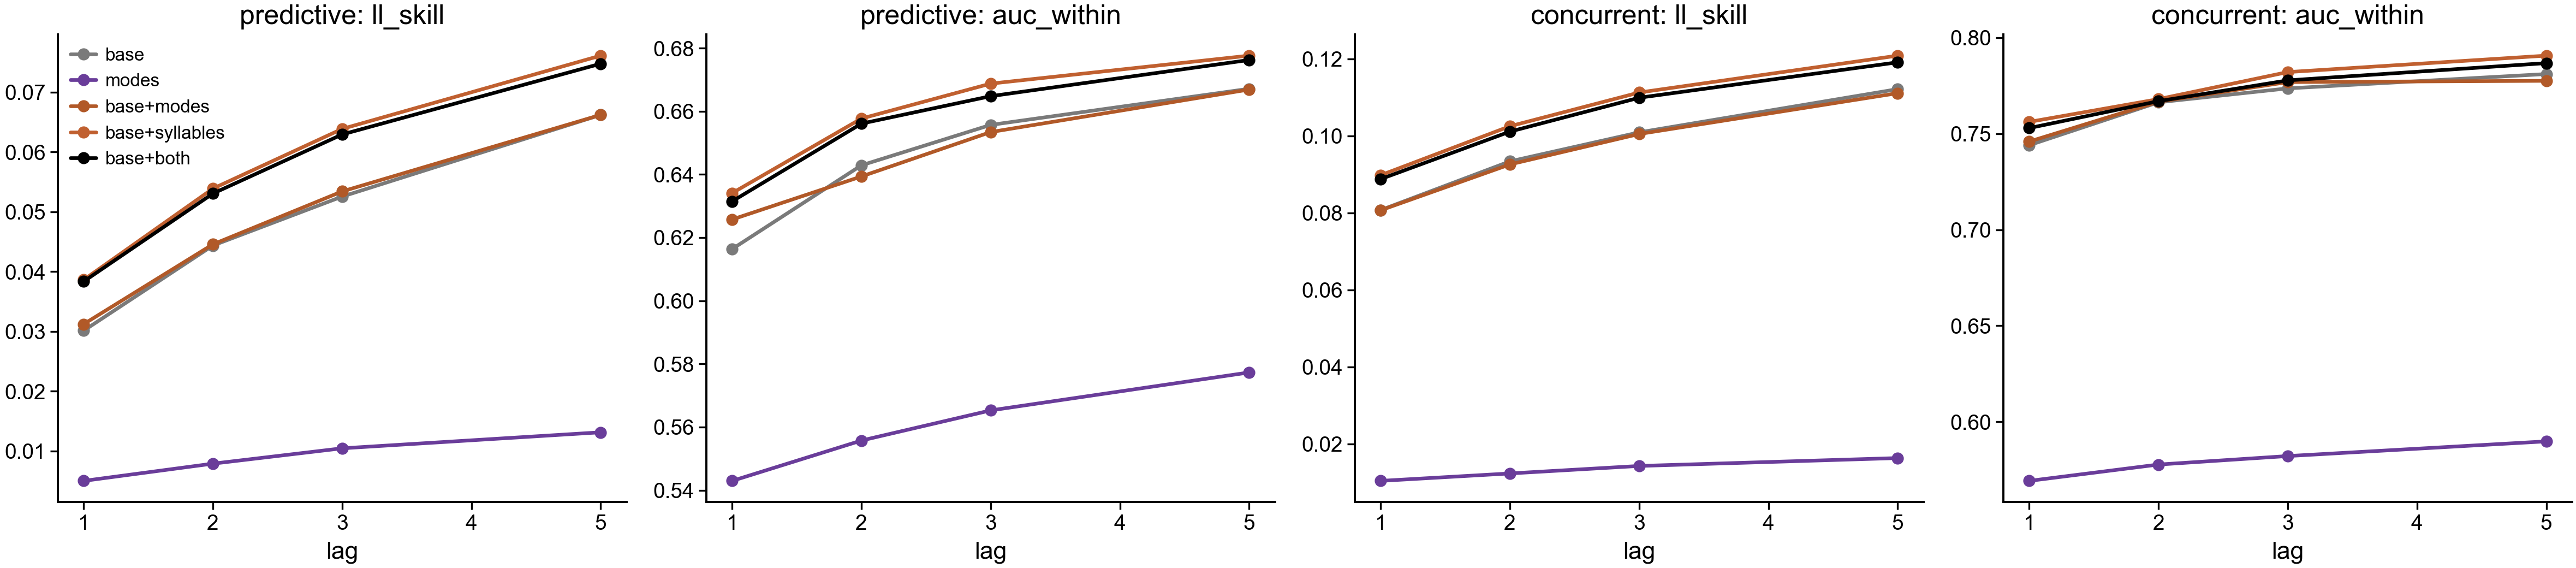

In [6]:
order = ['base', 'modes', 'base+modes', 'base+syllables', 'base+both']
colors = dict(zip(order, [ps.NEUTRAL, '#6a3d9a', '#b15928', '#c06030', 'k']))
fig, axes = plt.subplots(1, 2 * len(MODES), figsize=(12, 2.8))
for i, mode in enumerate(MODES):
    s = sweep[sweep['mode'] == mode]
    for j, metric in enumerate(['ll_skill', 'auc_within']):
        ax = axes[2 * i + j]
        for m in order:
            dd = s[s['model'] == m]
            ax.plot(dd['lag'], dd[metric], 'o-', color=colors[m], label=m, ms=3)
        ax.set(title=f'{mode}: {metric}', xlabel='lag')
axes[0].legend(frameon=False, fontsize=6)
fig.tight_layout(); plt.show()

## 3. Which modes, at which lag? (`MODE`, `LAG`, model `base+modes`)

{'n': 151889, 'events': 19918, 'base_rate': 0.1311352369164324, 'auc': 0.7086485084942102, 'ap': 0.3075891001379858, 'logloss': 0.3529073099940227, 'll_skill': 0.09255073378776557}


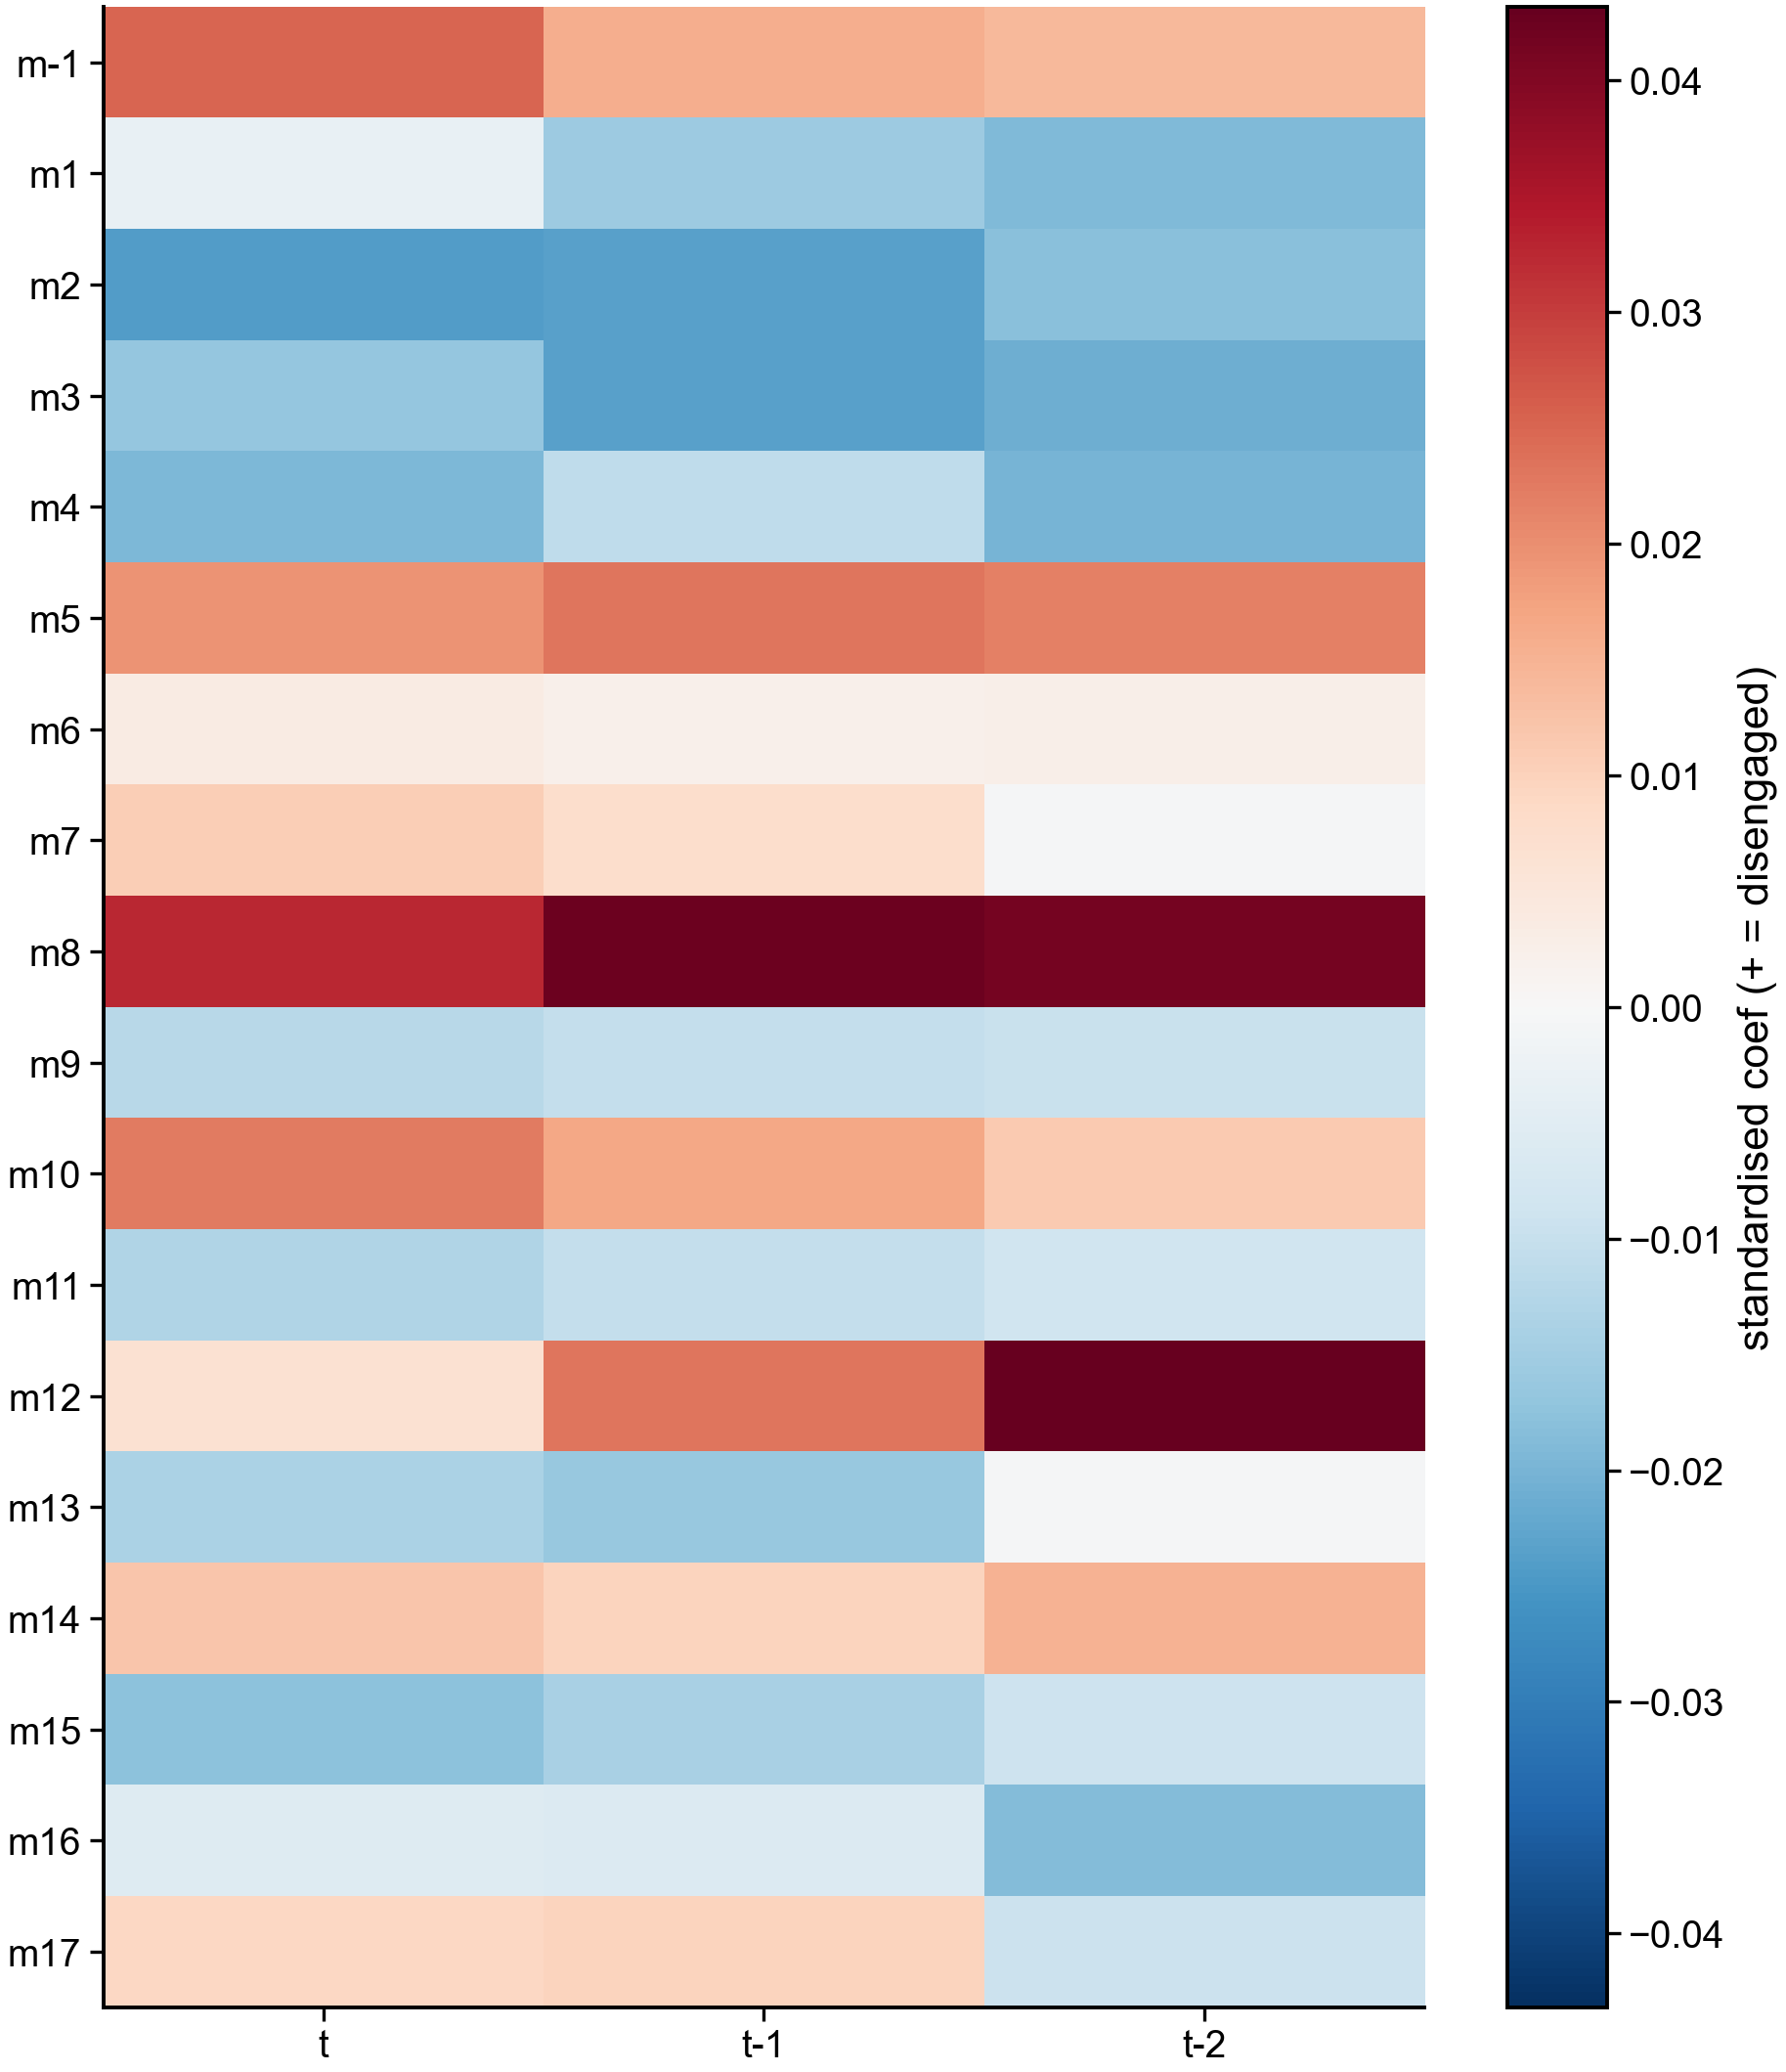

,group,n_cols,d_logloss_x1e3,sd
0,t-2,18,0.447125,0.071251
1,t-1,18,0.273441,0.060414
2,t,18,0.143337,0.049409


In [7]:
Xb, Xm, y, meta = td.design(df, TARGET, lag=LAG, mode=MODE, center=CENTER, features='modes')
X = pd.concat([Xb, Xm], axis=1)
p, p0, folds = tm.cross_validate(X, y, meta, CV, N_SPLITS)
print(tm.scores(y, p, p0))
coef = tm.coefficients(folds, X.columns)
C_ = coef.loc[Xm.columns, 'mean']
parts = C_.index.str.split('|', expand=True)
H = pd.Series(C_.values, index=pd.MultiIndex.from_tuples(parts)).droplevel(1).unstack(0)
H = H[[c for c in ['t'] + [f't-{l}' for l in range(1, LAG + 1)] if c in H.columns]]
H = H.loc[sorted(H.index, key=lambda s: int(s[1:]))]
v = np.abs(H.values).max()
fig, ax = plt.subplots(figsize=(3 + 0.6 * H.shape[1], 0.25 * len(H) + 1))
im = ax.imshow(H.values, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto')
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index)
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels(H.columns)
fig.colorbar(im, ax=ax, label='standardised coef (+ = disengaged)')
fig.tight_layout(); plt.show()
imp = tm.group_importance(X, y, meta, folds, td.feature_groups(Xm.columns, by=('lag',)), n_repeats=3)
imp

## 4. Along LD1

In [8]:
_, Xs, _, _ = td.design(df, TARGET, lag=LAG, mode=MODE, center=CENTER, features='syllables')
summary, preds, _ = tm.compare_models(Xb, Xm, y, meta, cv=CV, n_splits=N_SPLITS)
pm = tm.per_unit_scores(y, preds, meta, unit='mouse_name', min_events=20)
print(pd.DataFrame([tm.ld1_correlation(pm, c) for c in ['base_skill', 'full_skill', 'gain_skill', 'gain_auc']]).round(4).to_string(index=False))
skill_T, auc_T, bin_coefs = tm.transfer_matrix(Xb, Xm, y, meta, n_bins=N_LD1_BINS, n_splits=N_SPLITS)
print('\nheld-out skill, train (rows) x test (cols) LD1 bin:'); print(skill_T.round(4))
mode_rows = [c for c in bin_coefs.index if '|mode|' in c]
print('\ncorrelation of mode weights between LD1 bins:'); print(bin_coefs.loc[mode_rows].corr().round(2))

    metric  n     rho      p
base_skill 53 -0.0263 0.8518
full_skill 53 -0.0268 0.8491
gain_skill 53  0.0465 0.7408
  gain_auc 53  0.0251 0.8585



held-out skill, train (rows) x test (cols) LD1 bin:
             test bin 0  test bin 1  test bin 2
train bin 0      0.1094      0.0518      0.0814
train bin 1      0.1162      0.0504      0.1046
train bin 2      0.1091      0.0703      0.0949

correlation of mode weights between LD1 bins:
           LD1 bin 0  LD1 bin 1  LD1 bin 2
LD1 bin 0       1.00       0.42       0.38
LD1 bin 1       0.42       1.00       0.56
LD1 bin 2       0.38       0.56       1.00
